In [1]:
import os
import logging
import copy
import re
from glob import glob
from pathlib import Path
import numpy as np
import h5py
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from z2vqe.experiments.tools import clean_array
from z2vqe.experiments.qfim import get_rsat_lcritical

logging.basicConfig(level=logging.INFO)

In [2]:
configs = ['g_m_h', 'g_m_hsp', 'gsp_m_h', 'm_h', 'g_h']
num_fs = np.arange(2, 7)
datadir = Path('/data/iiyama/z2vqe')

## Subspace dimensions

In [3]:
generators = {}
subspaces = {}
hamiltonians = {}
for config in configs:
    generators[config] = {}
    subspaces[config] = {}
    hamiltonians[config] = {}
    for num_f in num_fs:
        with h5py.File(datadir / f'generators-{config}-{num_f}.h5', 'r', libver='latest') as source:
            generators[config][int(num_f)] = source['gen_mats'][()]
            subspaces[config][int(num_f)] = source['subspace'][()]
            hamiltonians[config][int(num_f)] = source['hamiltonian'][()]

In [4]:
subspace_dims = {conf: np.array([subspaces[conf][nf].shape[1] for nf in num_fs]) for conf in configs}
subspace_dims

{'g_m_h': array([  5,  10,  20,  47, 118]),
 'g_m_hsp': array([  8,  16,  36,  84, 224]),
 'gsp_m_h': array([  8,  16,  36,  84, 224]),
 'm_h': array([ 3,  6,  9, 18, 27]),
 'g_h': array([  5,  10,  20,  47, 118])}

In [5]:
# Adjust subspace reduction not due to symmetries
subspace_dims['g_h'][1] -= 1
subspace_dims['g_h'][3] -= 1

In [6]:
{conf: {nf: clean_array(np.trace(gen, axis1=1, axis2=2)) for nf, gen in gens.items()} for conf, gens in generators.items()}

{'g_m_h': {2: array([0., 4., 0.]),
  3: array([0., 4., 0.]),
  4: array([0., 8., 0.]),
  5: array([1.47615253e-12, 1.00000000e+01, 0.00000000e+00]),
  6: array([ 0., 16.,  0.])},
 'g_m_hsp': {2: array([0., 0., 0., 0.]),
  3: array([0., 0., 0., 0.]),
  4: array([0., 0., 0., 0.]),
  5: array([0., 0., 0., 0.]),
  6: array([0., 0., 0., 0.])},
 'gsp_m_h': {2: array([0., 0., 0., 0.]),
  3: array([0., 0., 0., 0.]),
  4: array([0., 0., 0., 0.]),
  5: array([0., 0., 0., 0.]),
  6: array([0., 0., 0., 0.])},
 'm_h': {2: array([0., 0.]),
  3: array([0., 0.]),
  4: array([0., 0.]),
  5: array([0., 0.]),
  6: array([0., 0.])},
 'g_h': {2: array([0., 0.]),
  3: array([0., 0.]),
  4: array([0., 0.]),
  5: array([0., 0.]),
  6: array([0., 0.])}}

INFO:matplotlib.mathtext:Substituting symbol S from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol S from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol S from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol S from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol S from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol S from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol S from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol S from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol S from STIXNonUnicode


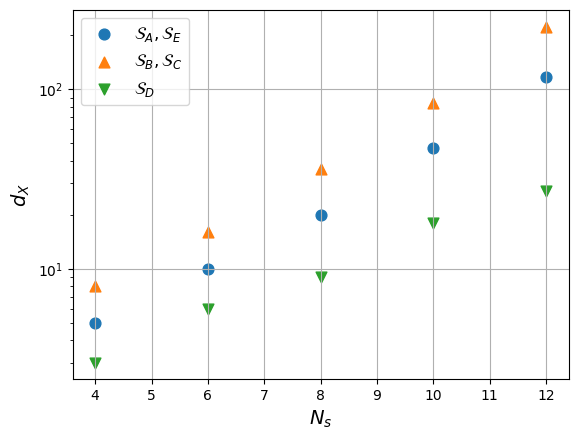

In [7]:
series = [
    ('g_m_h', r'$\mathcal{S}_A, \mathcal{S}_E$', 'o'),
    ('g_m_hsp', r'$\mathcal{S}_B, \mathcal{S}_C$', '^'),
    ('m_h', r'$\mathcal{S}_D$', 'v')
]
for config, symm, marker in series:
    plt.scatter(2 * num_fs, subspace_dims[config], 60., marker=marker, label=symm)

plt.grid()
plt.xlabel('$N_s$', fontsize=14)
plt.ylabel('$d_X$', fontsize=14)
plt.yscale('log')
plt.legend(fontsize=12)
plt.savefig('/home/iiyama/src/z2vqe/plots/symsect_dim.pdf')

## Verifying irreducibility

In [8]:
sbds = {}
reducibles = []

for config in configs:
    sbds[config] = {}
    for inf, num_f in enumerate(num_fs[:-1]):
        with h5py.File(datadir / f'sbd-{config}-{num_f}.h5', 'r', libver='latest') as source:
            tr = source['transform'][()]
            blocks = [source[f'block{i}'][()] for i in range(len(source.keys()) - 1)]
            sbds[config][num_f] = (tr, blocks)
            if len(blocks) > 1:
                reducibles.append((config, num_f))

In [9]:
reducibles

[('g_h', np.int64(3)), ('g_h', np.int64(5))]

## DLA dimensions

In [10]:
dlas = {}

for config in configs:
    dlas[config] = {}
    for num_f in num_fs:
        with h5py.File(datadir / f'dla-{config}-{num_f}.h5', 'r', libver='latest') as source:
            dlas[config][int(num_f)] = source['dla_dim'][()]

In [11]:
dlas

{'g_m_h': {2: np.int64(25),
  3: np.int64(100),
  4: np.int64(400),
  5: np.int64(2209),
  6: np.int64(13924)},
 'g_m_hsp': {2: np.int64(63),
  3: np.int64(255),
  4: np.int64(1296),
  5: np.int64(7056),
  6: np.int64(50176)},
 'gsp_m_h': {2: np.int64(63),
  3: np.int64(255),
  4: np.int64(1296),
  5: np.int64(7056),
  6: np.int64(50176)},
 'm_h': {2: np.int64(3),
  3: np.int64(6),
  4: np.int64(6),
  5: np.int64(9),
  6: np.int64(9)},
 'g_h': {2: np.int64(10),
  3: np.int64(36),
  4: np.int64(190),
  5: np.int64(2208),
  6: np.int64(13924)}}

In [12]:
for config, nf in [('g_m_hsp', 4), ('g_m_hsp', 5), ('g_m_hsp', 6), ('gsp_m_h', 4), ('gsp_m_h', 5), ('gsp_m_h', 6), ('g_h', 4), ('g_h', 6)]:
    print(config, nf)
    print(generators[config][nf].shape[1] ** 2, dlas[config][nf])
    print(clean_array(np.trace(generators[config][nf], axis1=1, axis2=2)))

g_m_hsp 4
1296 1296
[0. 0. 0. 0.]
g_m_hsp 5
7056 7056
[0. 0. 0. 0.]
g_m_hsp 6
50176 50176
[0. 0. 0. 0.]
gsp_m_h 4
1296 1296
[0. 0. 0. 0.]
gsp_m_h 5
7056 7056
[0. 0. 0. 0.]
gsp_m_h 6
50176 50176
[0. 0. 0. 0.]
g_h 4
400 190
[0. 0.]
g_h 6
13924 13924
[0. 0.]


In [13]:
for config, nf in reducibles:
    print(config, nf)
    print(sbds[config][nf][1][1].shape[1] ** 2, dlas[config][nf])
    print(clean_array(np.trace(sbds[config][nf][1][1], axis1=1, axis2=2)))

g_h 3
81 36
[0. 0.]
g_h 5
2116 2208
[0. 0.]


In [14]:
# Correct by hand
dlas['g_m_hsp'][4] -= 1
dlas['g_m_hsp'][5] -= 1
dlas['g_m_hsp'][6] -= 1
dlas['gsp_m_h'][4] -= 1
dlas['gsp_m_h'][5] -= 1
dlas['gsp_m_h'][6] -= 1
dlas['g_h'][4] = 190
for nf in [4, 5, 6]:
    dlas['g_h'][nf] = subspaces['g_h'][nf].shape[1] * (subspaces['g_h'][nf].shape[1] - 1) // 2

In [15]:
dla_dims = {conf: np.array([dlas[conf][nf] for nf in num_fs]) for conf in configs}

INFO:matplotlib.mathtext:Substituting symbol g from STIXGeneral
INFO:matplotlib.mathtext:Substituting symbol S from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol S from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol g from STIXGeneral
INFO:matplotlib.mathtext:Substituting symbol S from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol S from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol g from STIXGeneral
INFO:matplotlib.mathtext:Substituting symbol S from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol S from STIXNonUnicode


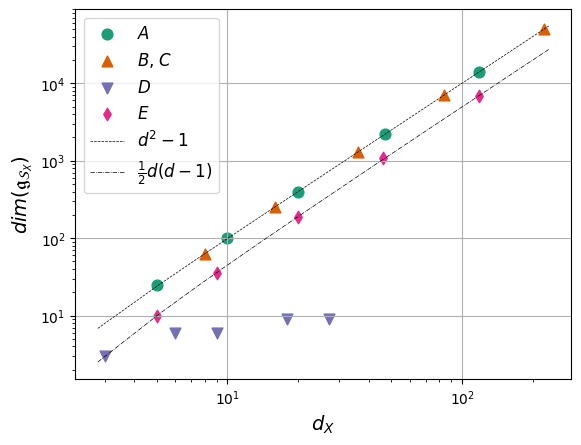

In [16]:
series = [
    ('g_m_h', '$A$', 'o'),
    ('gsp_m_h', '$B$, $C$', '^'),
    ('m_h', '$D$', 'v'),
    ('g_h', '$E$', 'd')
]
colors = mpl.color_sequences['Dark2']

for (config, label, marker), color in zip(series, colors):
    plt.scatter(subspace_dims[config], dla_dims[config], 40. if marker == 'd' else 60., color=color, marker=marker, label=label)
xfine = np.linspace(min(s[0] for s in subspace_dims.values()) - 0.2, max(s[-1] for s in subspace_dims.values()) + 10, 100)
plt.plot(xfine, xfine ** 2 - 1, color='k', linestyle='--', linewidth=0.5, label='$d^2 - 1$')
plt.plot(xfine, xfine * (xfine - 1) / 2, color='k', linestyle='-.', linewidth=0.5, label=r'$\frac{1}{2}d(d-1)$')

plt.xscale('log')
plt.yscale('log')
plt.legend(fontsize=12);
plt.xlabel('$d_X$', fontsize=14)
plt.ylabel(r'$dim (\mathfrak{g}_{\mathcal{S}_X})$', fontsize=14)
plt.grid()

plt.savefig('/home/iiyama/src/z2vqe/plots/dim_dla.pdf')

## QFIM saturation

In [17]:
rsats = {}
lcriticals = {}
qfim_ranks = {}
qfim_nls = {}

for config in configs:
    rsats[config] = {}
    lcriticals[config] = {}
    qfim_ranks[config] = {}
    qfim_nls[config] = {}
    for num_f in num_fs:
        with h5py.File(datadir / f'qfim-{config}-{num_f}.h5', 'r', libver='latest') as source:
            ranks = source['ranks'][()]
            num_layers = source['num_layers'][()]
            rsat, lcritical = get_rsat_lcritical(ranks, num_layers)
            rsats[config][int(num_f)] = rsat
            lcriticals[config][int(num_f)] = lcritical
            qfim_ranks[config][int(num_f)] = ranks
            qfim_nls[config][int(num_f)] = num_layers

In [18]:
rsats

{'g_m_h': {2: np.float64(8.0),
  3: np.float64(18.0),
  4: np.float64(38.0),
  5: np.float64(92.0),
  6: np.float64(234.0)},
 'g_m_hsp': {2: np.float64(14.0),
  3: np.float64(30.0),
  4: np.float64(70.0),
  5: np.float64(166.0),
  6: np.float64(446.0)},
 'gsp_m_h': {2: np.float64(14.0),
  3: np.float64(30.0),
  4: np.float64(70.0),
  5: np.float64(166.0),
  6: np.float64(446.0)},
 'm_h': {2: np.float64(2.0),
  3: np.float64(4.0),
  4: np.float64(4.0),
  5: np.float64(6.0),
  6: np.float64(6.0)},
 'g_h': {2: np.float64(4.0),
  3: np.float64(8.0),
  4: np.float64(19.0),
  5: np.float64(45.0),
  6: np.float64(117.0)}}

In [19]:
lcriticals

{'g_m_h': {2: np.int64(4),
  3: np.int64(7),
  4: np.int64(14),
  5: np.int64(32),
  6: np.int64(79)},
 'g_m_hsp': {2: np.int64(5),
  3: np.int64(8),
  4: np.int64(18),
  5: np.int64(42),
  6: np.int64(112)},
 'gsp_m_h': {2: np.int64(5),
  3: np.int64(9),
  4: np.int64(19),
  5: np.int64(43),
  6: np.int64(113)},
 'm_h': {2: np.int64(2),
  3: np.int64(5),
  4: np.int64(4),
  5: np.int64(5),
  6: np.int64(5)},
 'g_h': {2: np.int64(3),
  3: np.int64(5),
  4: np.int64(11),
  5: np.int64(24),
  6: np.int64(61)}}

In [20]:
rsat_nums = {conf: np.array([rsats[conf][nf] for nf in num_fs]) for conf in configs}

<>:20: SyntaxWarning: invalid escape sequence '\o'
<>:20: SyntaxWarning: invalid escape sequence '\o'
/tmp/ipykernel_1068411/3902587505.py:20: SyntaxWarning: invalid escape sequence '\o'
  plt.ylabel('$\overline{R}_{\psi}$', fontsize=14)
INFO:matplotlib.mathtext:Substituting symbol g from STIXGeneral
INFO:matplotlib.mathtext:Substituting symbol S from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol S from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol g from STIXGeneral
INFO:matplotlib.mathtext:Substituting symbol S from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol S from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol g from STIXGeneral
INFO:matplotlib.mathtext:Substituting symbol S from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol S from STIXNonUnicode


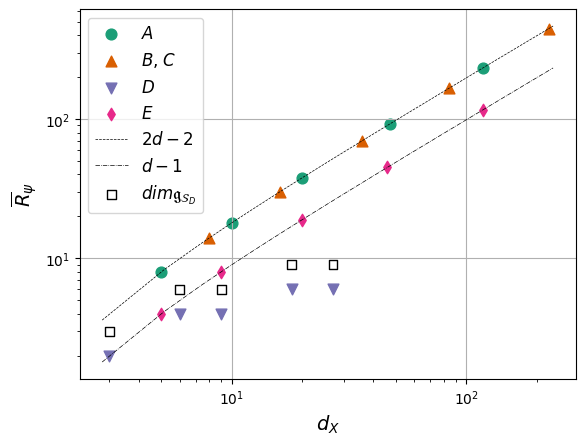

In [21]:
series = [
    ('g_m_h', '$A$', 'o'),
    ('gsp_m_h', '$B$, $C$', '^'),
    ('m_h', '$D$', 'v'),
    ('g_h', '$E$', 'd')
]
colors = mpl.color_sequences['Dark2']

for (config, label, marker), color in zip(series, colors):
    plt.scatter(subspace_dims[config], rsat_nums[config], 40. if marker == 'd' else 60., color=color, marker=marker, label=label)
xfine = np.linspace(min(s[0] for s in subspace_dims.values()) - 0.2, max(s[-1] for s in subspace_dims.values()) + 10, 100)
plt.plot(xfine, xfine * 2 - 2, color='k', linestyle='--', linewidth=0.5, label='$2d - 2$')
plt.plot(xfine, xfine - 1, color='k', linestyle='-.', linewidth=0.5, label='$d - 1$')
plt.scatter(subspace_dims['m_h'], dla_dims['m_h'], 40., color='k', marker='s', facecolor='none', label=r'$dim \mathfrak{g}_{\mathcal{S}_D}$')

plt.xscale('log')
plt.yscale('log')
plt.legend(fontsize=12);
plt.xlabel('$d_X$', fontsize=14)
plt.ylabel('$\overline{R}_{\psi}$', fontsize=14)
plt.grid()

plt.savefig('/home/iiyama/src/z2vqe/plots/qfim_rsat.pdf')

### Maximum QFIM rank and loss landscape

In [22]:
nls = {}
qfim_ranks = {}
vqe_losses = {}
vqe_grads = {}
for config in configs:
    nls[config] = {}
    qfim_ranks[config] = {}
    vqe_losses[config] = {}
    vqe_grads[config] = {}
    for num_f in num_fs:
        with h5py.File(datadir / f'vqe-{config}-{num_f}.h5', 'r', libver='latest') as source:
            nls[config][num_f] = source['num_layers'][()]
            qfim_ranks[config][num_f] = source['ranks'][()]
            vqe_losses[config][num_f] = source['losses'][()]
            vqe_grads[config][num_f] = source['gradients'][()]

INFO:matplotlib.mathtext:Substituting symbol L from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol L from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol L from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol L from STIXNonUnicode


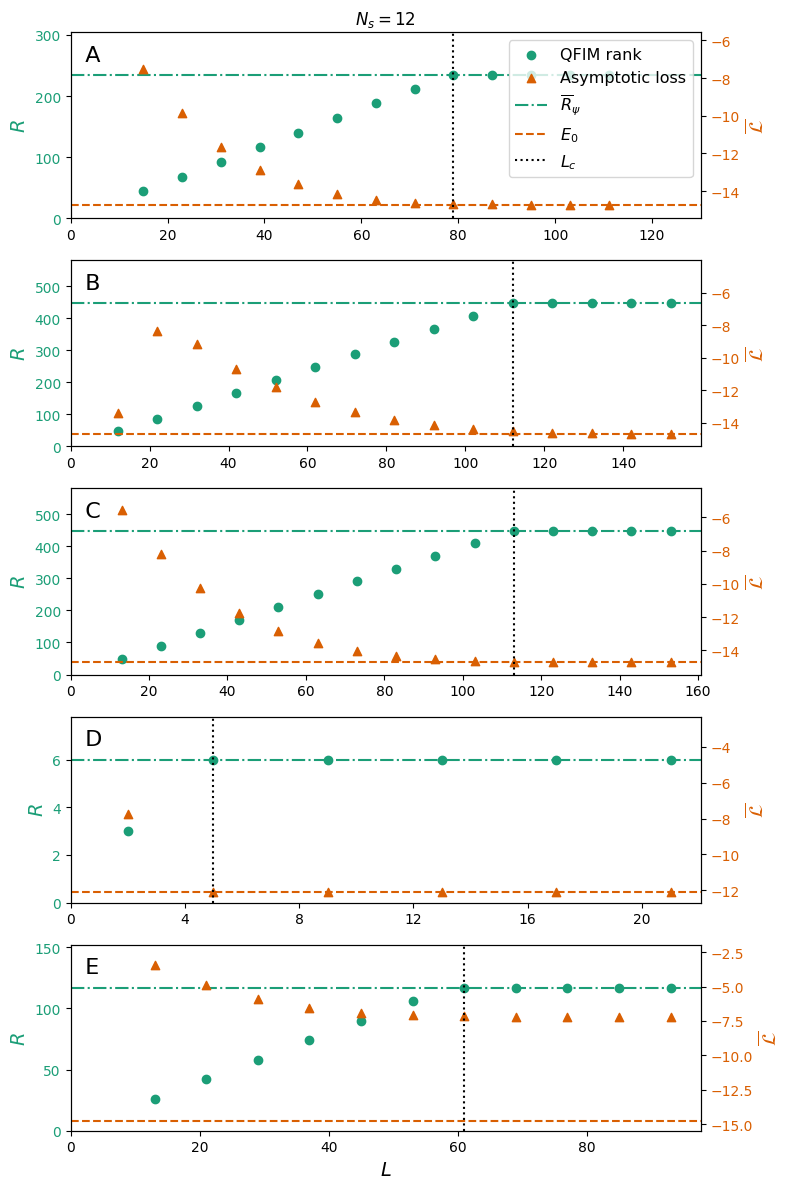

In [34]:
num_f = 6
fig, axs = plt.subplots(5, 1, figsize=(8, 12))
colors = mpl.color_sequences['Dark2']

for iconfig, (config, cname) in enumerate(zip(configs, ['A', 'B', 'C', 'D', 'E'])):
    axl = axs[iconfig]
    axl.text(0, np.max(qfim_ranks[config][num_f]) * 1.1, f'  {cname}', fontsize=16, ha='left')
    hqr = axl.scatter(nls[config][num_f], np.mean(qfim_ranks[config][num_f], axis=1), color=colors[0],
                      marker='o', label='QFIM rank')
    hrpsi = axl.axhline(rsats[config][num_f], color=colors[0], linestyle='-.', label=r'$R_{\psi}$')
    axl.set_ylabel('$R$', color=colors[0], fontsize=14)
    axl.tick_params(axis='y', labelcolor=colors[0])
    axl.set_ylim(0., np.max(qfim_ranks[config][num_f]) * 1.3)

    axr = axl.twinx()
    exact_e0 = np.linalg.eigvalsh(hamiltonians[config][num_f])[0]
    hal = axr.scatter(nls[config][num_f], np.mean(vqe_losses[config][num_f], axis=1), color=colors[1],
                      marker='^', label='Asymptotic loss')
    he0 = axr.axhline(exact_e0, color=colors[1], linestyle='--', label='$E_0$')
    axr.set_ylabel(r'$\overline{\mathcal{L}}$', color=colors[1], fontsize=14)
    axr.set_ylim(exact_e0 * 1.05, np.max(vqe_losses[config][num_f]) * 0.9)
    axr.tick_params(axis='y', labelcolor=colors[1])

    axr.set_xlim(0., np.max(nls[config][num_f]) * 1.05)
    # axr.set_xlim(0., 160.)
    hlc = axr.axvline(lcriticals[config][num_f], color='k', linestyle=':', label='$L_c$')

    if iconfig == 0:
        axr.set_xlim(0., 130.)
        axr.legend(
            [hqr, hal, hrpsi, he0, hlc],
            ['QFIM rank', 'Asymptotic loss', r'$\overline{R}_{\psi}$', '$E_0$', '$L_c$'],
            fontsize=11.5
        )
    if iconfig == 3:
        ticks = np.arange(0, 23, 4)
        axr.set_xticks(ticks, labels=[f'{x}' for x in ticks])


    # axr.scatter(nls[config][num_f], np.mean(vqe_grads[config][num_f], axis=1))

axs[0].set_title('$N_s = 12$')
axs[-1].set_xlabel('$L$', fontsize=14)

fig.tight_layout()
fig.savefig('/home/iiyama/src/z2vqe/plots/rank_loss.pdf')

### Decay rate

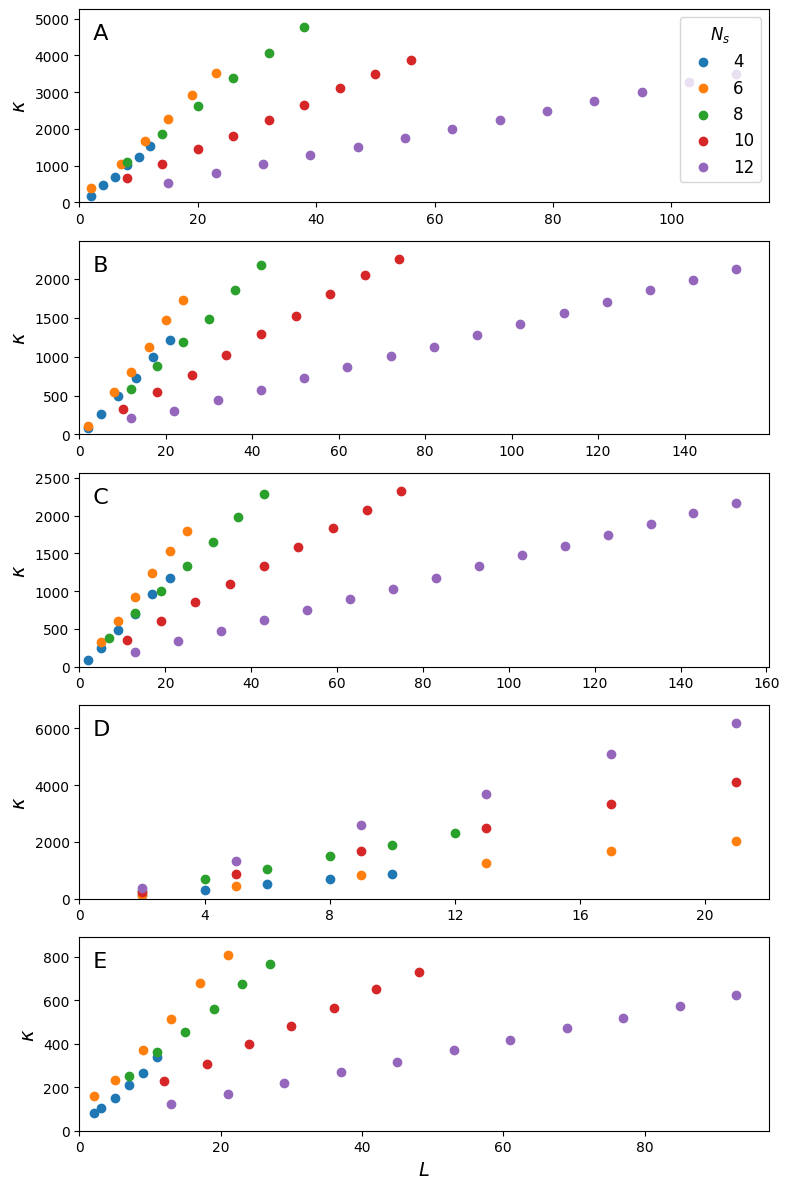

In [31]:
fig, axs = plt.subplots(5, 1, figsize=(8, 12))

for iconfig, (config, cname) in enumerate(zip(configs, ['A', 'B', 'C', 'D', 'E'])):
    ax = axs[iconfig]
    mean_ends = []
    for num_f in num_fs:
        y = np.mean(vqe_grads[config][num_f], axis=1)
        ax.scatter(nls[config][num_f], y, label=f'{2 * num_f}')
        mean_ends.append(y[-1])
    ax.text(0, np.max(mean_ends) * 0.93, f'  {cname}', fontsize=16, ha='left')
    ax.set_xlim(0., np.max(nls[config][6]) * 1.05)
    ax.set_ylim(0., np.max(mean_ends) * 1.1)
    ax.set_ylabel(r'$\kappa$', fontsize=14)

    if iconfig == 0:
        ax.legend(title='$N_s$', fontsize=12, title_fontsize=12)
    if iconfig == 3:
        ticks = np.arange(0, 23, 4)
        ax.set_xticks(ticks, labels=[f'{x}' for x in ticks])

axs[-1].set_xlabel('$L$', fontsize=14)
fig.tight_layout()
fig.savefig('/home/iiyama/src/z2vqe/plots/decay_rate.pdf')

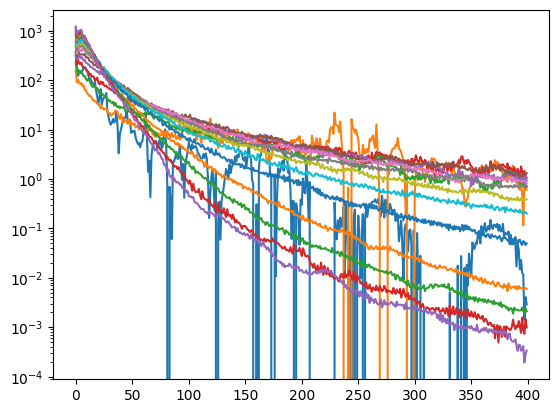

In [53]:
plt.plot(np.mean(-dloss[:, :, :ntherm] / th_ssize, axis=1).T)
plt.yscale('log')

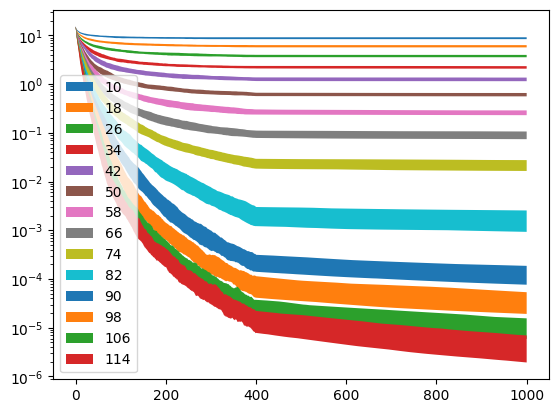

In [54]:
x = np.arange(ntherm + maxiter + 1)
for nl, energies in zip(nls[1:], loss[1:]):
    err = energies - exact_e0
    ylow = np.quantile(err, 0.25, axis=0)
    yhigh = np.quantile(err, 0.75, axis=0)
    plt.fill_between(x, ylow, yhigh, label=f'{nl}')
plt.yscale('log')
plt.legend();

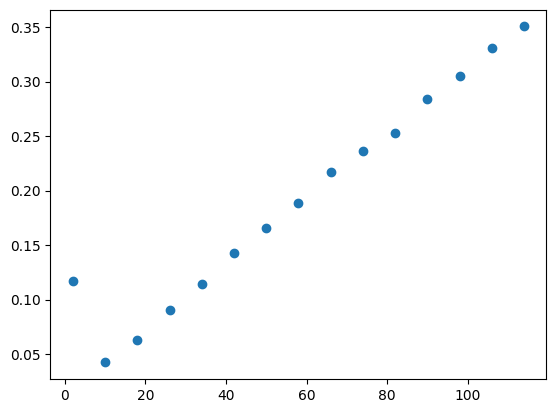

In [24]:
plt.scatter(nls, np.mean(np.max(-dloss, axis=2), axis=1))

In [35]:
with h5py.File(datadir / f'vqe-{config}-{num_f}-th400-it0.h5', 'r', libver='latest') as source:
    nls = source['num_layers'][()]
    loss = source['energies'][()]
    stepsizes = source['therm_stepsizes'][()]
    dloss = np.diff(loss, axis=2)

In [36]:
stepsizes.shape

(15, 128, 400)

In [37]:
dloss.shape

(15, 128, 400)

In [38]:
dloss[0]

array([[-1.33479877e+00, -5.97132355e-01, -2.89569180e-01, ...,
        -3.08315661e-05, -2.94555951e-05, -2.86343334e-05],
       [-7.01015816e-01, -6.38468562e-01, -4.88203828e-01, ...,
         3.04704487e-07, -1.11382196e-07, -5.23700979e-07],
       [-1.86411260e+00, -1.74586296e+00, -1.05289858e+00, ...,
        -6.47132575e-05, -7.12107208e-05, -7.34838419e-05],
       ...,
       [-9.29132109e-01, -8.33329250e-01, -1.17630562e+00, ...,
         2.74707043e-03,  3.38073618e-03,  3.76143094e-03],
       [-1.30737614e+00, -7.53405478e-02, -5.75505358e-02, ...,
        -1.10038533e-05, -6.06386492e-06, -1.31384925e-06],
       [-1.93497520e+00, -1.83784441e-01, -1.27825169e-01, ...,
        -5.27410551e-08, -4.73200523e-08, -4.02644909e-08]],
      shape=(128, 400))

In [55]:
x = np.arange(stepsizes.shape[-1])
for nl, diffs, ss in zip(nls, dloss, stepsizes):
    dldt = -diffs / ss
#     ylow = np.quantile(dldt, 0.25, axis=0)
#     yhigh = np.quantile(dldt, 0.75, axis=0)
#     plt.fill_between(x, ylow, yhigh, label=f'{nl}')
    plt.plot(x, np.mean(dldt, axis=0), label=f'{nl}')
plt.yscale('log')
plt.legend();

ValueError: operands could not be broadcast together with shapes (128,1000) (128,400) 

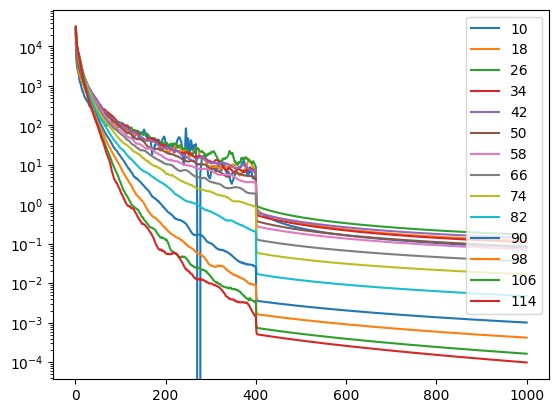

In [43]:
for nl, diffs in zip(nls[1:], dloss[1:]):
    # plt.plot(x[1:101], -np.mean(diffs, axis=0)[:100] / ssize, label=f'{nl}')
    plt.plot(x[1:], -np.mean(diffs, axis=0) / ssize, label=f'{nl}')

plt.yscale('log')
plt.legend();

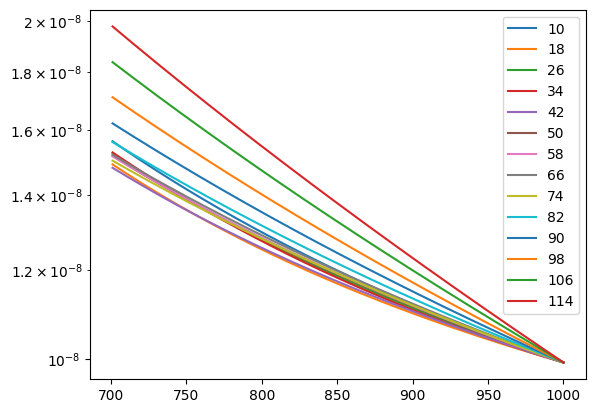

In [42]:
scale_to = -np.mean(dloss[-1, :, -1])
for nl, diffs in zip(nls[1:], dloss[1:]):
    # plt.plot(x[1:101], -np.mean(diffs, axis=0)[:100] / ssize, label=f'{nl}')
    scale = scale_to / -np.mean(diffs[:, -1])
    plt.plot(x[701:], -np.mean(diffs, axis=0)[700:] * scale, label=f'{nl}')

plt.yscale('log')
plt.legend();

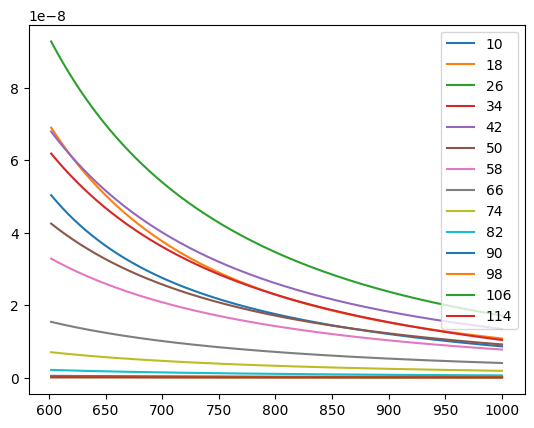

In [38]:
for nl, diffs in zip(nls[1:], dloss[1:]):
    plt.plot(x[602:], np.mean(np.diff(diffs[:, 600:], axis=1), axis=0), label=f'{nl}')

# plt.yscale('log')
plt.legend();

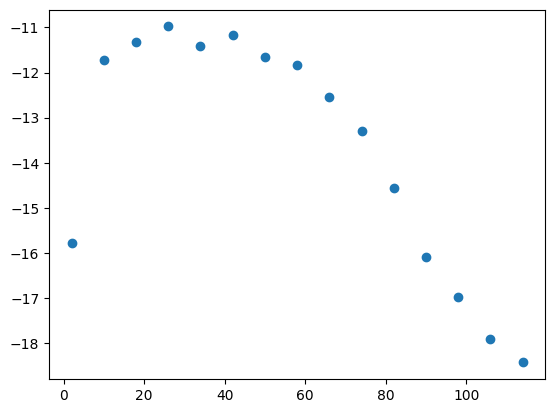

In [32]:
plt.scatter(nls, np.log(-np.mean(dloss[:, :, -1], axis=1)))

In [97]:
num_layers = {}
energies = {}
ntherms = {}
stepsizes = {}
qntks = {}
qntk_errs = {}

for config in configs:
    num_layers[config] = {}
    energies[config] = {}
    ntherms[config] = {}
    stepsizes[config] = {}
    qntks[config] = {}
    qntk_errs[config] = {}
    for num_f in num_fs:
        with h5py.File(datadir / f'vqe-{config}-{num_f}.h5', 'r', libver='latest') as source:
            num_layers[config][num_f] = source['num_layers'][()]
            loss = source['energies'][()]
            ssize = source['run_stepsize'][()]
            energies[config][num_f] = loss
            ntherms[config][num_f] = source['therm_stepsizes'].shape[-1]
            stepsizes[config][num_f] = ssize

            dloss = np.diff(loss, axis=2)
            rdloss = dloss[:, :, 1:] / np.where(dloss[:, :, :-1] == 0., 1., dloss[:, :, :-1])
            rdloss = np.where(rdloss <= 0., 1., rdloss)
            lrdloss = np.log(rdloss)
            # qntks[config][num_f] = np.mean(lrdloss[:, :, -1], axis=1) / ssize
            qntks[config][num_f] = np.quantile(lrdloss[:, :, -1], 0.5, axis=1) / ssize
            qntk_errs[config][num_f] = (
                np.quantile(lrdloss[:, :, -1], 0.25, axis=1) / ssize,
                np.quantile(lrdloss[:, :, -1], 0.75, axis=1) / ssize
            )

In [58]:
stepsizes

{'g_m_h': {np.int64(2): np.float64(0.0002),
  np.int64(3): np.float64(0.0002),
  np.int64(4): np.float64(0.0002),
  np.int64(5): np.float64(0.0002),
  np.int64(6): np.float64(0.0002)},
 'g_m_hsp': {np.int64(2): np.float64(0.0002),
  np.int64(3): np.float64(0.0002),
  np.int64(4): np.float64(0.0002),
  np.int64(5): np.float64(0.0002),
  np.int64(6): np.float64(0.0001)},
 'gsp_m_h': {np.int64(2): np.float64(0.0002),
  np.int64(3): np.float64(0.0002),
  np.int64(4): np.float64(0.0002),
  np.int64(5): np.float64(0.0002),
  np.int64(6): np.float64(0.0001)},
 'm_h': {np.int64(2): np.float64(5e-05),
  np.int64(3): np.float64(5e-05),
  np.int64(4): np.float64(5e-05),
  np.int64(5): np.float64(3e-05),
  np.int64(6): np.float64(3e-05)},
 'g_h': {np.int64(2): np.float64(1e-05),
  np.int64(3): np.float64(5e-05),
  np.int64(4): np.float64(5e-05),
  np.int64(5): np.float64(5e-05),
  np.int64(6): np.float64(5e-05)}}

In [59]:
qntks['gsp_m_h'][6]

array([-30.99355286, -40.35752517, -39.27513435, -40.78827359,
       -41.46185219, -43.04814108, -44.72049275, -42.65335855,
       -43.0580713 , -42.9392801 , -43.18518311, -45.15005143,
       -46.8302497 , -48.1704122 , -47.81852247, -52.78732596,
       -56.12032911, -63.34550251, -67.37541194, -72.083988  ])

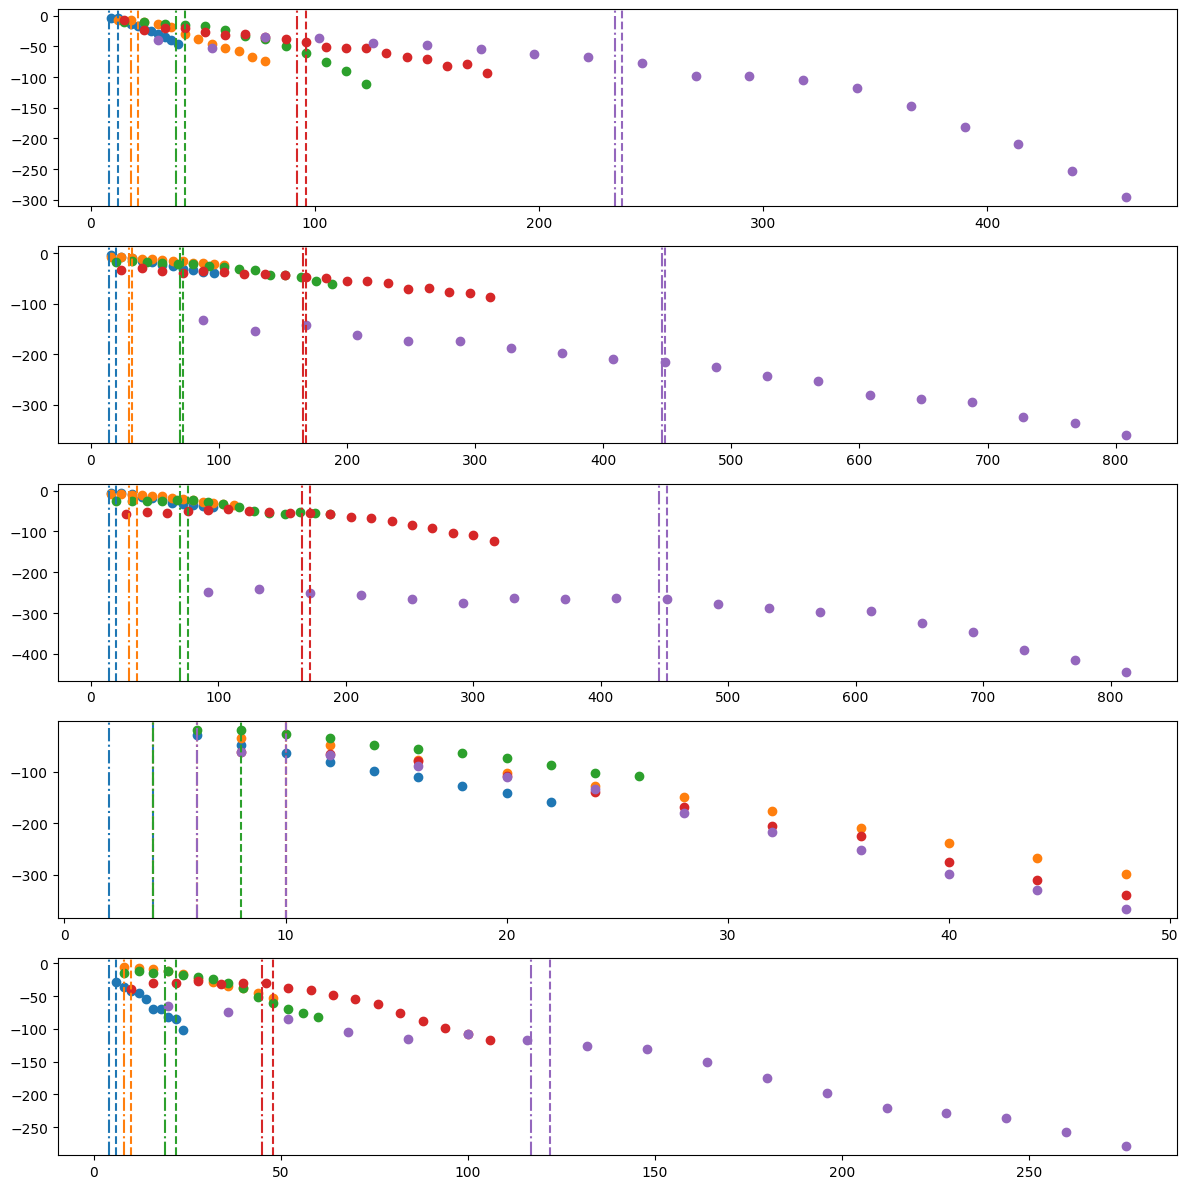

In [60]:
fig, axs = plt.subplots(5, 1, figsize=(12, 12))

for config, num_terms, ax in zip(configs, [3, 4, 4, 2, 2], axs):
    for num_f, sdim in zip(num_fs, subspace_dims[config]):
        mc = lcriticals[config][num_f] * num_terms
        x = num_layers[config][num_f][1:] * num_terms
        y = qntks[config][num_f][1:] * (sdim ** 2)
        y /= np.trace(hamiltonians[config][num_f] @ hamiltonians[config][num_f])
        paths = ax.scatter(x, y, label=f'$N_s={2 * num_f}$')
        ax.axvline(mc, color=paths.get_facecolor(), linestyle='--')
        ax.axvline(rsats[config][num_f], color=paths.get_facecolor(), linestyle='-.')
        # if config not in ['m_h', 'g_h']:
        #     ax.set_xscale('log')

fig.tight_layout()

In [65]:
configs

['g_m_h', 'g_m_hsp', 'gsp_m_h', 'm_h', 'g_h']

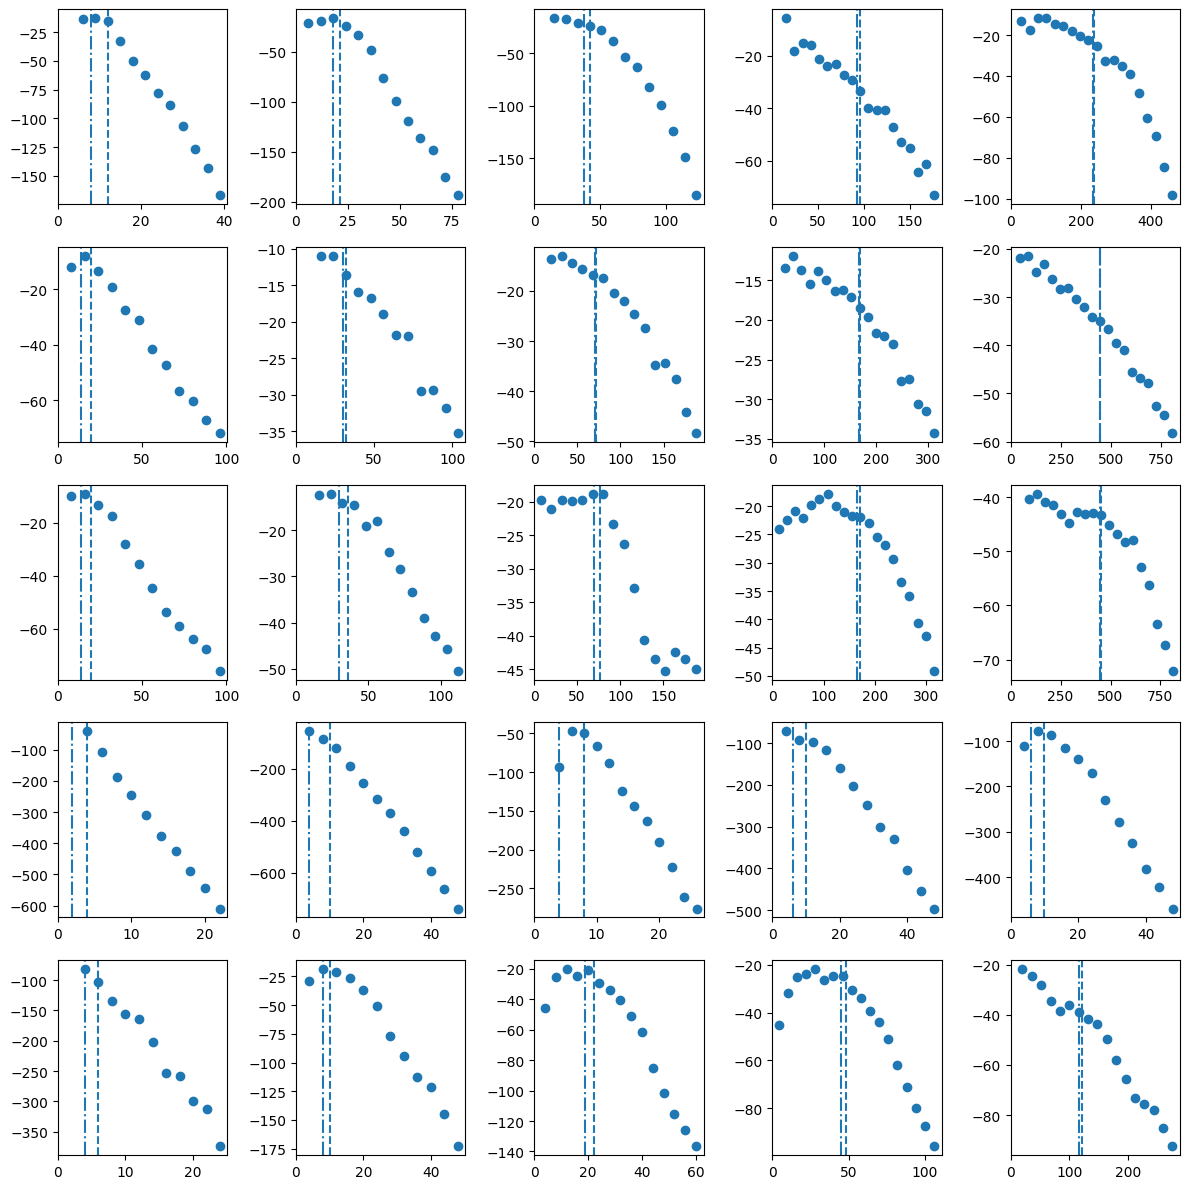

In [66]:
outliers = [
    ('g_m_h', 4), ('g_m_h', 5), ('g_m_h', 6),
    ('g_m_hsp', 3), ('g_m_hsp', 4), ('g_m_hsp', 5),
    ('gsp_m_h', 3), ('gsp_m_h', 6),
    ('g_h', 6)
]

fig, axs = plt.subplots(5, 5, figsize=(12, 12))

for config, num_terms, axrow in zip(configs, [3, 4, 4, 2, 2], axs):
    for num_f, ax in zip(num_fs, axrow):
        mc = lcriticals[config][num_f] * num_terms
        x = num_layers[config][num_f] * num_terms
        y = qntks[config][num_f]
        if (config, num_f) in outliers:
            x = x[1:]
            y = y[1:]
        paths = ax.scatter(x, y, label=f'$N_s={2 * num_f}$')
        ax.axvline(mc, color=paths.get_facecolor(), linestyle='--')
        ax.axvline(rsats[config][num_f], color=paths.get_facecolor(), linestyle='-.')
        xmax = ax.get_xlim()[1]
        ax.set_xlim(0., xmax)
        # if config not in ['m_h', 'g_h']:
        #     ax.set_xscale('log')

fig.tight_layout()

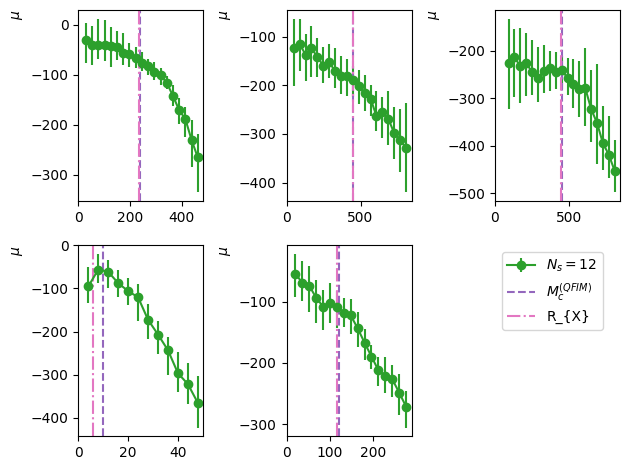

In [110]:
outliers = [
    ('g_m_h', 4), ('g_m_h', 5), ('g_m_h', 6),
    ('g_m_hsp', 3), ('g_m_hsp', 4), ('g_m_hsp', 5),
    ('gsp_m_h', 3), ('gsp_m_h', 6),
    ('g_h', 6)
]

fig, axs = plt.subplots(2, 3)
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
num_f = 6

for config, num_terms, ax in zip(configs, [3, 4, 4, 2, 2], fig.axes):
    mc = lcriticals[config][num_f] * num_terms
    x = num_layers[config][num_f] * num_terms
    y = qntks[config][num_f].copy()
    yerr = np.array([y - qntk_errs[config][num_f][0], qntk_errs[config][num_f][1] - y])
    yscale = (subspace_dims[config][-1] ** 2) / np.trace(hamiltonians[config][num_f] @ hamiltonians[config][num_f])
    y *= yscale
    yerr *= yscale
    if (config, num_f) in outliers:
        x = x[1:]
        y = y[1:]
        yerr = yerr[:, 1:]
    errorbars = ax.errorbar(x, y, yerr=yerr, color=colors[2], marker='o', label=f'$N_s={2 * num_f}$')
    mcline = ax.axvline(mc, color=colors[4], linestyle='--', label='$M_{c}^{(QFIM)}$')
    rsatline = ax.axvline(rsats[config][num_f], color=colors[6], linestyle='-.', label='R_{X}')
    xmax = ax.get_xlim()[1]
    # ax.text('M')
    ax.set_ylabel(r'$\mu$', x=0., y=1., horizontalalignment='right')
    ax.set_xlim(0., xmax)
    # if config not in ['m_h', 'g_h']:
    #     ax.set_xscale('log')

fig.axes[-1].set_axis_off()
fig.axes[-1].legend(handles=[errorbars, mcline, rsatline], loc='upper left')

fig.tight_layout()

(0.0, 850.0)

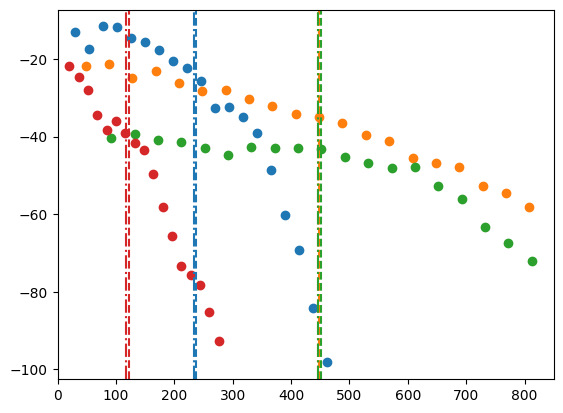

In [71]:
for config, num_terms in zip(configs, [3, 4, 4, 2, 2]):
    if config == 'm_h':
        continue
    num_f = 6
    mc = lcriticals[config][num_f] * num_terms
    x = num_layers[config][num_f] * num_terms
    y = qntks[config][num_f]
    if (config, num_f) in outliers:
        x = x[1:]
        y = y[1:]
    paths = plt.scatter(x, y, label=f'$N_s={2 * num_f}$')
    plt.axvline(mc, color=paths.get_facecolor(), linestyle='--')
    plt.axvline(rsats[config][num_f], color=paths.get_facecolor(), linestyle='-.')

plt.xlim(0., 850.)

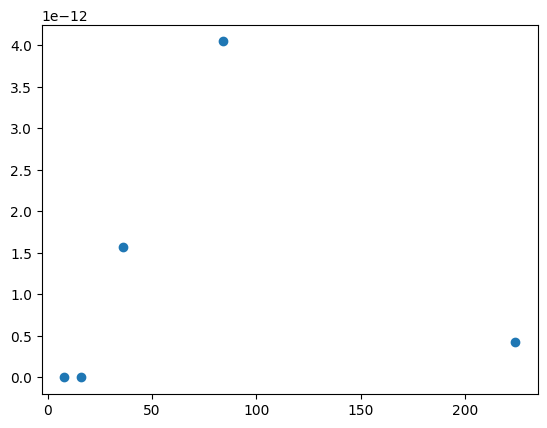

In [ ]:
config = 'gsp_m_h'
nfs = np.arange(2, 7)
plt.scatter(subspace_dims[config], [np.trace(hamiltonians[config][num_f] @ hamiltonians[config][num_f]) for num_f in nfs])

In [81]:
paths.get_facecolor()

array([[0.58039216, 0.40392157, 0.74117647, 1.        ]])

In [ ]:
subspace_dims = {}
dlas = {}
qfim_ranks = {}
subspace_dims = np.zeros((len(configs), len(num_fs)), dtype=int)
dlas = np.zeros((len(configs), len(num_fs)), dtype=int)
qfim_ranks = np.zeros((len(configs), len(num_fs)), dtype=int)
for iconfig, config in enumerate(configs):
    for inum, num_f in enumerate(num_fs):
        path = pathtemp.format(config=config, num_fermions=num_f)
        if not os.path.exists(path):
            continue
        with h5py.File(path, 'r', libver='latest') as source:
            print(config, num_f, source['blocks'][()])
            subspace_dims[iconfig, inum] = source['subspace'].shape[1]
            dlas[iconfig, inum] = source['dla'].shape[0]
            qfim_ranks[iconfig, inum] = source['qfim_ranks'][-1]

g_m_h 2 [5]
g_m_h 3 [10]
g_m_h 4 [20]
g_m_h 5 [47]
g_m_h 6 [118]
g_m_hsp 2 [8]
g_m_hsp 3 [16]
g_m_hsp 4 [36]
g_m_hsp 5 [84]
gsp_m_h 2 [8]
gsp_m_h 3 [16]
gsp_m_h 4 [36]
gsp_m_h 5 [84]
g_h 2 [5]
g_h 3 [1 9]
g_h 4 [20]
g_h 5 [ 1 46]
g_h 6 [118]
m_h 2 [2 3]
m_h 3 [1 3 6]
m_h 6 [118]


(np.int64(3), np.int64(128))

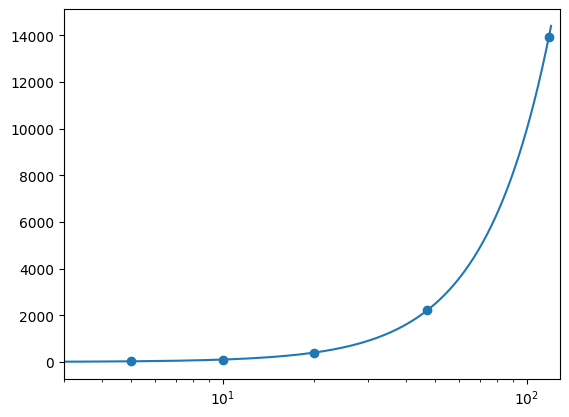

In [ ]:
xfine = np.linspace(1., 120., 200)
plt.scatter(subspace_dims[0], dlas[0])
plt.plot(xfine, xfine * xfine - 1.)
plt.xscale('log')
plt.xlim(np.min(subspace_dims[:, 0]) - 2, np.max(subspace_dims[:, -1]) + 10)

In [25]:
a = np.random.random((5, 5)) + 1.j * np.random.random((5, 5))
a += a.conjugate().T
a *= 1.j
b = np.random.random((5, 5)) + 1.j * np.random.random((5, 5))
b += b.conjugate().T
b *= 1.j

In [26]:
np.trace(a.conjugate().T @ b)

np.complex128(33.433754460414775+4.718447854656915e-16j)

In [28]:
atri = np.concatenate([a[i, i+1:] for i in range(5)])
btri = np.concatenate([b[i, i+1:] for i in range(5)])
c = atri.conjugate() @ btri
print(c + c.conjugate() + np.diagonal(a.conjugate()) @ np.diagonal(b))
print(c.real * 2. + np.diagonal(a.conjugate()) @ np.diagonal(b))

(33.43375446041477+0j)
(33.43375446041477+0j)


## DLA dims

In [13]:
dlas = {}
for config in configs[]:
    dlas[config] = {}
    for num_f in num_fs:
        with h5py.File(datadir / f'dla-{config}-{num_f}.h5', 'r', libver='latest') as source:
            dlas[config][int(num_f)] = source['dla'][()]

FileNotFoundError: [Errno 2] Unable to synchronously open file (unable to open file: name = '/data/iiyama/z2vqe/dla-g_m_h-7.h5', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)

In [16]:
[dlas['g_m_h'][nf].shape for nf in num_fs]

[(25, 5, 5), (100, 10, 10), (400, 20, 20), (1971, 47, 47), (10768, 118, 118)]

In [12]:
x = np.arange(35, 47)
x ** 2 + (47 - x) ** 2

array([1369, 1417, 1469, 1525, 1585, 1649, 1717, 1789, 1865, 1945, 2029,
       2117])

In [16]:
44 ** 2

1936

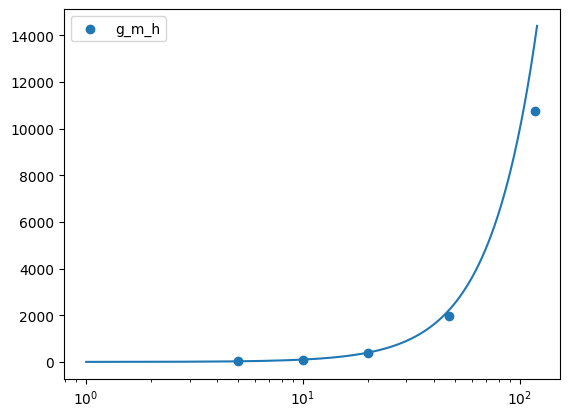

In [ ]:
for config in ['g_m_h']:
    subspace_dims = np.array([subspaces[config][nf].shape[1] for nf in num_fs])
    dlas = np.array([dlas[config][nf].shape[0] for nf in num_fs])
    plt.scatter(subspace_dims, dlas, label=config)

xfine = np.linspace(1., 120., 200)
plt.plot(xfine, xfine * xfine - 1.)
plt.xscale('log')
plt.legend();